In [ ]:
import numpy as np
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import os

In [ ]:
import os
from pathlib import Path

In [ ]:
all_paths = []
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        all_paths.append(os.path.join(dirname, filename))
all_paths[:10]

['/kaggle/input/brain-tumor/Brain Tumor.csv',
 '/kaggle/input/brain-tumor/bt_dataset_t3.csv',
 '/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor/Image3202.jpg',
 '/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor/Image1153.jpg',
 '/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor/Image1465.jpg',
 '/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor/Image688.jpg',
 '/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor/Image233.jpg',
 '/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor/Image3561.jpg',
 '/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor/Image1166.jpg',
 '/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor/Image1975.jpg']

In [ ]:
bt_path = Path("/kaggle/input/brain-tumor/")
img_path =Path("/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor")
bt_path.exists(), img_path.exists()

(True, True)

In [ ]:
bt_ds_df = pd.read_csv(bt_path / "Brain Tumor.csv")
display(bt_ds_df.head(3))

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155


In [ ]:

img_path = Path("/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor/")
working_path = Path("/kaggle/working")
pos_path = working_path / "positive_cancer"
neg_path = working_path / "negative_cancer"

import os

# Create directory for positive and negative cancer image
if not pos_path.exists():
    os.mkdir("positive_cancer")
    os.mkdir("negative_cancer")
else:
    print("Directory existed")

In [ ]:
os.listdir("/kaggle/working")

['__notebook__.ipynb', 'positive_cancer', 'negative_cancer']

In [ ]:
# Copying image on particular cancer class
from tqdm import tqdm
import shutil
image_class = bt_ds_df.copy()
image_class = image_class[["Image", "Class"]].to_numpy()
for data in tqdm(image_class):
    img_name = data[0]
    img_class = data[1]

    if img_class == 1:
        shutil.copy(img_path/f"{img_name}.jpg", pos_path/f"{img_name}.jpg")
    else:
        shutil.copy(img_path/f"{img_name}.jpg", neg_path/f"{img_name}.jpg")

100%|██████████| 3762/3762 [00:16<00:00, 228.71it/s]


In [ ]:
dataset_path = working_path/"dataset"
train_path = dataset_path/"train"
test_path = dataset_path/"test"
validate_path = dataset_path/"validate"

if not dataset_path.exists():
    os.mkdir(dataset_path)
else:
    print("dataset directory existed")

if not train_path.exists():
    os.mkdir(train_path)
    os.mkdir(train_path/"positive")
    os.mkdir(train_path/"negative")
else:
    print("train directory existed")

if not test_path.exists():
    os.mkdir(test_path)
    os.mkdir(test_path/"positive")
    os.mkdir(test_path/"negative")
else:
    print("test directory existed")

if not validate_path.exists():
    os.mkdir(validate_path)
    os.mkdir(validate_path/"positive")
    os.mkdir(validate_path/"negative")
else:
    print("validate directory existed")

train_path.exists(), test_path.exists(), validate_path.exists()

(True, True, True)

In [ ]:
list_pos = os.listdir(pos_path)
list_neg = os.listdir(neg_path)

len_pos = len(list_pos)
len_neg = len(list_neg)

len_pos_test = int(len_pos * 0.2)
len_neg_test = int(len_neg * 0.2)

len_pos_train = len_pos - len_pos_test
len_neg_train = len_neg - len_neg_test

len_pos_train, len_pos_test, len_neg_train, len_neg_test

(1347, 336, 1664, 415)

In [ ]:
# train
train_pos = list_pos[len_pos_test:]
train_neg = list_neg[len_neg_test:]

# validate
val_pos = train_pos[:int(len(train_pos)*0.15)]
val_neg = train_neg[:int(len(train_neg)*0.15)]

# test
test_pos = list_pos[:len_pos_test]
test_neg = list_neg[:len_neg_test]
test_pos = [x for x in test_pos if x not in val_pos]
test_neg = [x for x in test_neg if x not in val_neg]


len(train_pos), len(train_neg), len(test_pos), len(test_neg), len(val_pos), len(val_neg)

(1347, 1664, 336, 415, 202, 249)

In [ ]:
# Copying image on particular cancer class

## Train dataset
print("INFO: Splitting train pos dataset...")
for train_img_pos in tqdm(train_pos):
    shutil.copy(pos_path/f"{train_img_pos}", train_path/"positive"/f"{train_img_pos}")
print("INFO: Completed\n")
print("INFO: Splitting train neg dataset...")
for train_img_neg in tqdm(train_neg):
    shutil.copy(neg_path/f"{train_img_neg}", train_path/"negative"/f"{train_img_neg}")
print("INFO: Completed\n")

##  Test dataset
print("INFO: Splitting test pos dataset...")
for test_img_pos in tqdm(test_pos):
    shutil.copy(pos_path/f"{test_img_pos}", test_path/"positive"/f"{test_img_pos}")
print("INFO: Completed\n")
print("INFO: Splitting test neg dataset...")
for test_img_neg in tqdm(test_neg):
    shutil.copy(neg_path/f"{test_img_neg}", test_path/"negative"/f"{test_img_neg}")
print("INFO: Completed\n")


## Validation dataset
print("INFO: Splitting validate pos dataset...")
for validate_img_pos in tqdm(val_pos):
    shutil.copy(pos_path/f"{validate_img_pos}", validate_path/"positive"/f"{validate_img_pos}")
print("INFO: Completed\n")
print("INFO: Splitting validate neg dataset...")
for validate_img_neg in tqdm(val_neg):
    shutil.copy(neg_path/f"{validate_img_neg}", validate_path/"negative"/f"{validate_img_neg}")
print("INFO: Completed\n")

INFO: Splitting train pos dataset...


100%|██████████| 1347/1347 [00:00<00:00, 7244.29it/s]


INFO: Completed

INFO: Splitting train neg dataset...


100%|██████████| 1664/1664 [00:00<00:00, 7577.08it/s]


INFO: Completed

INFO: Splitting test pos dataset...


...

INFO: Completed

INFO: Splitting validate pos dataset...


100%|██████████| 202/202 [00:00<00:00, 7646.79it/s]


INFO: Completed

INFO: Splitting validate neg dataset...


100%|██████████| 249/249 [00:00<00:00, 8150.70it/s]

INFO: Completed



In [ ]:
df_log = bt_ds_df.copy()

X = df_log.drop(["Image", "Class"], axis=1)
y = df_log[["Class"]]

X.columns, y.columns

(Index(['Mean', 'Variance', 'Standard Deviation', 'Entropy', 'Skewness',
        'Kurtosis', 'Contrast', 'Energy', 'ASM', 'Homogeneity', 'Dissimilarity',
        'Correlation', 'Coarseness'],
       dtype='object'),
 Index(['Class'], dtype='object'))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((2256, 13), (2256, 1), (753, 13), (753, 1), (753, 13), (753, 1))

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_data_generator = ImageDataGenerator(rescale=1./255,
                    rotation_range=15,
                    width_shift_range=0.1,
                    height_shift_range=0.1,
                    shear_range=0.1,
                    brightness_range=[0.5, 1.5],
                    horizontal_flip=True,
                    vertical_flip=True)
test_data_generator = ImageDataGenerator(rescale=1./255)

train_data = train_data_generator.flow_from_directory(
                    train_path,
                    batch_size=16,
                    target_size=(224, 224),
                    class_mode="binary", # 1/0 cancer
                    seed=42
)

test_data = train_data_generator.flow_from_directory(
                    test_path,
                    batch_size=16,
                    target_size=(224, 224),
                    class_mode="binary", # 1/0 cancer
                    seed=42
)
val_data = train_data_generator.flow_from_directory(
                    validate_path,
                    batch_size=16,
                    target_size=(224, 224),
                    class_mode="binary", # 1/0 cancer
                    seed=42
)

train_data, test_data, val_data

Found 3011 images belonging to 2 classes.
Found 751 images belonging to 2 classes.
Found 451 images belonging to 2 classes.


(<keras.src.legacy.preprocessing.image.DirectoryIterator at 0x7a74d6b91c60>,
 <keras.src.legacy.preprocessing.image.DirectoryIterator at 0x7a74d6b91390>)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # For binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,679,041 (36.92 MB)

 Trainable params: 9,679,041 (36.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(train_data,
                    epochs=100,  # Adjust the number of epochs as needed
                    validation_data=val_data)

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/100


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  1/189 ━━━━━━━━━━━━━━━━━━━━ 37:11 12s/step - accuracy: 0.1875 - loss: 0.6964

I0000 00:00:1712380242.469214      97 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1712380242.490426      97 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


111/189 ━━━━━━━━━━━━━━━━━━━━ 20s 257ms/step - accuracy: 0.6526 - loss: 0.6010

...

W0000 00:00:1712380287.427790      99 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


189/189 ━━━━━━━━━━━━━━━━━━━━ 63s 271ms/step - accuracy: 0.6826 - loss: 0.5822 - val_accuracy: 0.8093 - val_loss: 0.4512
Epoch 2/100


W0000 00:00:1712380293.445129      98 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


189/189 ━━━━━━━━━━━━━━━━━━━━ 47s 241ms/step - accuracy: 0.7643 - loss: 0.5083 - val_accuracy: 0.7783 - val_loss: 0.5120
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 47s 241ms/step - accuracy: 0.7830 - loss: 0.4932 - val_accuracy: 0.8226 - val_loss: 0.4195
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 47s 242ms/step - accuracy: 0.7704 - loss: 0.4853 - val_accuracy: 0.8337 - val_loss: 0.4103
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 47s 242ms/step - accuracy: 0.7828 - loss: 0.4685 - val_accuracy: 0.8337 - val_loss: 0.4050
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 48s 244ms/step - accuracy: 0.7806 - loss: 0.4743 - val_accuracy: 0.8271 - val_loss: 0.4139
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 47s 243ms/step - accuracy: 0.7823 - loss: 0.4744 - val_accuracy: 0.8625 - val_loss: 0.3722
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 47s 241ms/step - accuracy: 0.8058 - loss: 0.4495 - val_accuracy: 0.8492 - val_loss: 0.4035
Epoch 9/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 47s 240ms/step - accuracy: 0.7896 - loss: 0.460

W0000 00:00:1712385023.441497      99 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


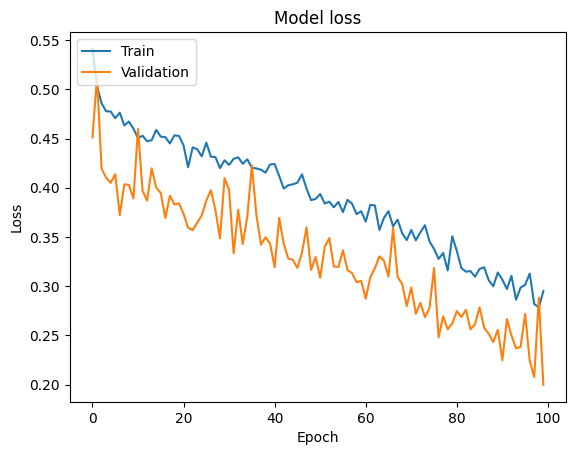

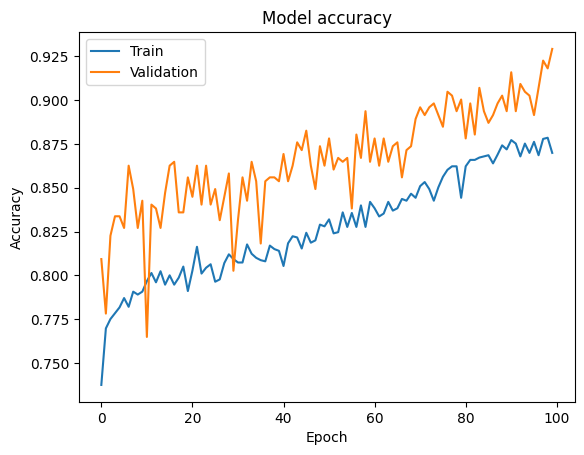

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
